# Profile Likelihoods and Fisher Matrices

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/dev/examples/04-inference/profile_likelihood_and_fisher.ipynb)

Three ways to put an error bar on a parameter, in decreasing order
of cost:

| | cost | assumes |
|---|---|---|
| **MCMC** | ~10⁵ likelihood evaluations | nothing |
| **profile likelihood** | ~10³ | nothing, but reports a different thing |
| **Fisher matrix** | ~2n² | the posterior is Gaussian |

They answer subtly different questions, and the differences matter
exactly where the posterior is interesting — near a boundary, or
when a parameter is only constrained through a degeneracy.

This notebook fits CPL to real data with all three and compares
them.

## Setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e ".[dev]"

    # The editable install runs in a subprocess, so this already-running
    # kernel does not see the .pth it writes -- and `import CosmoFit`
    # would resolve to the bare checkout directory instead (same name,
    # and /content is on sys.path). Point sys.path at src/ directly.
    import importlib
    sys.path.insert(0, os.path.abspath("src"))
    importlib.invalidate_caches()
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e \".[dev]\" from the repository root).")

Not running in Colab -- assuming CosmoFit is already installed (pip install -e ".[dev]" from the repository root).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import Fitter
from CosmoFit.cosmology.models import CPL, LCDM

plt.rcParams["figure.dpi"] = 110

## 1. A fit to start from

CPL is `w(a) = w0 + wa(1-a)`. Both extra parameters are needed for
the comparison to be interesting: `wa` is only weakly constrained by
these data, so its posterior is the non-Gaussian one.

In [3]:
fit = Fitter(
    model=CPL,
    datasets=["cc", "desi", "pantheon"],
    free_params=["H0", "Omega_m", "w0", "wa", "rd"],
    initial={"H0": 70.0, "Omega_m": 0.3, "w0": -1.0, "wa": 0.0,
             "rd": 147.0},
)

best = fit.best_fit(restarts=3, seed=0)
for name, value in zip(fit.free_params, best.x):
    print(f"  {name:8s} = {value: .4f}")
print(f"\n  chi2 = {best.fun:.3f}")

  H0       =  69.1047
  Omega_m  =  0.3157
  w0       = -0.8432
  wa       = -0.6767
  rd       =  144.5563
  chi2 = 1480.750


## 2. The Fisher matrix

The curvature of χ² at the best fit,
`F_ij = ½ ∂²χ²/∂θ_i∂θ_j`. Invert it and the diagonal gives the
parameter errors — under the assumption that the posterior is a
Gaussian centred there.

It costs about `2n²` likelihood evaluations: for six parameters,
under a hundred, against the hundred thousand an MCMC will take.

In [4]:
fisher = fit.fisher()

print(f"{'parameter':>10s} {'best fit':>12s} {'Fisher sigma':>14s}")
for name, value, error in zip(fit.free_params, fisher["theta"], fisher["errors"]):
    print(f"{name:>10s} {value:12.4f} {error:14.4f}")

 parameter     best fit   Fisher sigma
        H0      69.1047         3.1153
   Omega_m       0.3157         0.0176
        w0      -0.8432         0.0780
        wa      -0.6767         0.5865
        rd     144.5563         6.3607


### A singular Fisher matrix is information, not a failure

Note what is *not* in `free_params`: `MB`, the supernova absolute
magnitude. Pantheon+ marginalizes it analytically by default
(`marginalize_MB=True`), so freeing it adds a parameter the
likelihood cannot see — an exactly flat direction.

An MCMC would happily sample that flat direction and return a
posterior for `MB` that is just the prior. The Fisher matrix cannot:
a flat direction is a zero eigenvalue, the matrix is singular, and
inverting it raises. Try it and see.

In [5]:
import numpy.linalg as la

with_mb = Fitter(
    model=CPL,
    datasets=["cc", "desi", "pantheon"],
    free_params=["H0", "Omega_m", "w0", "wa", "rd", "MB"],
    initial={"H0": 70.0, "Omega_m": 0.3, "w0": -1.0, "wa": 0.0,
             "rd": 147.0, "MB": -19.3},
)
with_mb.best_fit(restarts=1, seed=0)

try:
    with_mb.fisher()
except la.LinAlgError as exc:
    print(f"LinAlgError: {exc}")
    print("\n-> MB does nothing here. The Fisher matrix said so in one call.")

LinAlgError: Singular matrix
-> MB does nothing here. The Fisher matrix said so in one call.


The full covariance is there too, which is what makes the Fisher
matrix useful for forecasting — the correlations, not just the
diagonal.

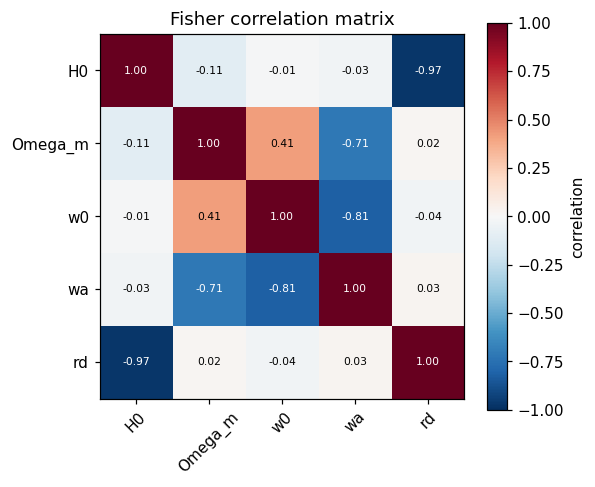

In [6]:
cov = fisher["covariance"]
sigma = fisher["errors"]
correlation = cov / np.outer(sigma, sigma)

fig, ax = plt.subplots(figsize=(5.5, 4.6))
im = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(fit.free_params)), fit.free_params, rotation=45)
ax.set_yticks(range(len(fit.free_params)), fit.free_params)
for i in range(len(fit.free_params)):
    for j in range(len(fit.free_params)):
        ax.text(j, i, f"{correlation[i, j]:.2f}", ha="center", va="center",
                fontsize=7,
                color="white" if abs(correlation[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, label="correlation")
ax.set_title("Fisher correlation matrix")
fig.tight_layout()

`w0` and `wa` are strongly anti-correlated — the data constrain a
combination of them far better than either alone. That is the
degeneracy the `w0`–`wa` plane is usually plotted in.

## 3. An MCMC, to check it against

The Fisher matrix is only as good as its Gaussian assumption. The
way to find out is to run the chain.

In [7]:
fit.run_mcmc(nwalkers=36, nsteps=3000, burnin=600, seed=0, progress=True)
print(fit.result)

  0%|          | 0/3000 [00:00<?, ?it/s]


  0%|          | 2/3000 [00:00<02:57, 16.90it/s]


  0%|          | 8/3000 [00:00<01:19, 37.76it/s]


  0%|          | 14/3000 [00:00<01:06, 44.69it/s]


  1%|          | 20/3000 [00:00<01:02, 47.79it/s]


...

100%|█████████▉| 2995/3000 [01:12<00:00, 23.08it/s]


100%|█████████▉| 2998/3000 [01:12<00:00, 20.90it/s]


100%|██████████| 3000/3000 [01:12<00:00, 41.18it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 48;
tau: [53.92388625 63.70969039 45.36704733 58.75577924 54.80386302]


FitResult(model=CPL, datasets=['cc', 'desi', 'pantheon'], free_params=['H0', 'Omega_m', 'w0', 'wa', 'rd'])
  BestFitResult(H0=69.1047, Omega_m=0.315726, w0=-0.843153, wa=-0.676699, rd=144.556, chi2=1480.7504, AIC=1490.75, BIC=1517.85)
  MCMCResult(36 walkers x 3000 steps, burnin=600, NOT converged, acceptance=0.51)
  H0 = 68.4335 (+3.3/-3.2)
  Omega_m = 0.312475 (+0.017/-0.023)
  w0 = -0.85519 (+0.078/-0.068)
  wa = -0.581551 (+0.62/-0.62)
  rd = 146.097 (+7/-6.5)


In [8]:
summary = fit.summary()

print(f"{'parameter':>10s} {'MCMC -sigma':>12s} {'MCMC +sigma':>12s} "
      f"{'Fisher':>10s} {'ratio':>8s}")
for name, error in zip(fit.free_params, fisher["errors"]):
    s = summary[name]
    mcmc = 0.5 * (s["minus"] + s["plus"])
    print(f"{name:>10s} {s['minus']:12.4f} {s['plus']:12.4f} "
          f"{error:10.4f} {error / mcmc:8.2f}")

 parameter  MCMC -sigma  MCMC +sigma     Fisher    ratio
        H0       3.1775       3.3447     3.1153     0.96
   Omega_m       0.0230       0.0173     0.0176     0.87
        w0       0.0679       0.0781     0.0780     1.07
        wa       0.6155       0.6232     0.5865     0.95
        rd       6.5124       7.0408     6.3607     0.94


Where the ratio is near 1 the posterior really is Gaussian and the
Fisher matrix would have saved a chain. Where it is not — and where
the MCMC's `+σ` and `−σ` differ from each other — the posterior is
skewed and Fisher is reporting a number that does not exist.

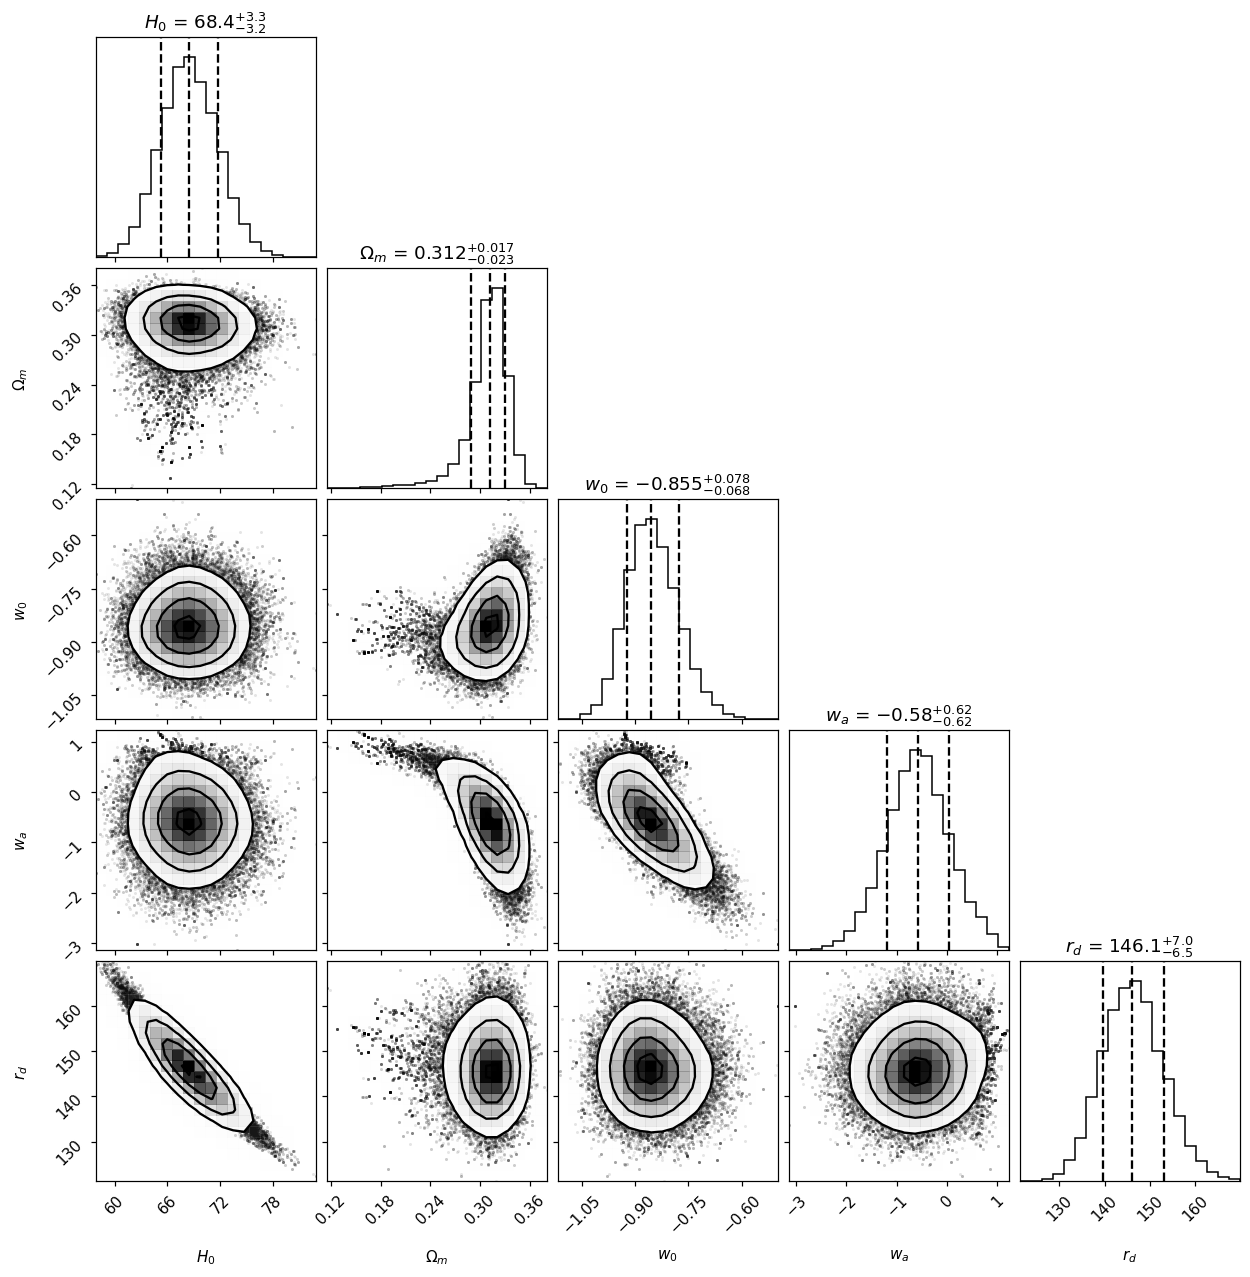

In [9]:
fit.plots.corner();

## 4. The profile likelihood

χ² minimized over every *other* parameter, at each fixed value of
the one you care about. That is a different object from a marginal
posterior: marginalizing **integrates** over the other parameters,
profiling **optimizes** over them.

The difference shows up whenever a parameter's likelihood is
constrained but its prior volume is not — a marginal posterior then
carries a volume effect that a profile does not.

  w0 = -1.35  chi2 = 1532.8752


  w0 = -1.3  chi2 = 1523.5723


  w0 = -1.25  chi2 = 1514.9301


  w0 = -1.2  chi2 = 1506.9026


  w0 = -1.15  chi2 = 1499.8188


...

  w0 = -0.85  chi2 = 1480.7463


  w0 = -0.8  chi2 = 1481.6777


  w0 = -0.75  chi2 = 1482.7512


  w0 = -0.7  chi2 = 1485.6097


  w0 = -0.65  chi2 = 1487.1777


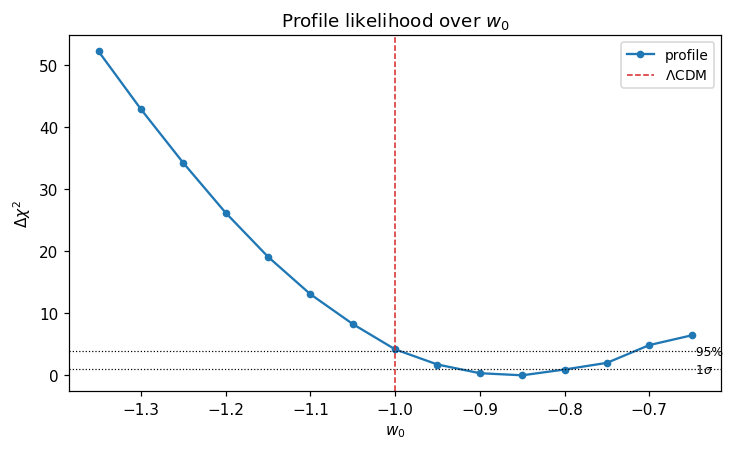

In [10]:
w0_grid = np.linspace(-1.35, -0.65, 15)
profile = fit.profile("w0", w0_grid, seed=0, progress=True)

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(profile["values"], profile["delta_chi2"], "o-", lw=1.5, ms=4,
        label="profile")

for level, label in [(1.0, r"$1\sigma$"), (3.84, "95%")]:
    ax.axhline(level, color="k", lw=0.8, ls=":")
    ax.text(w0_grid[-1], level, f" {label}", va="center", fontsize=8)

ax.axvline(-1.0, color="tab:red", lw=1.0, ls="--", label=r"$\Lambda$CDM")
ax.set_xlabel("$w_0$")
ax.set_ylabel(r"$\Delta\chi^2$")
ax.set_title("Profile likelihood over $w_0$")
ax.legend(fontsize=9)
fig.tight_layout()

### Profile against marginal

Overlaying the marginal posterior, converted to a Δχ² scale, shows
how much the two differ for this parameter.

/tmp/ipykernel_14889/3579380066.py:6: RuntimeWarning: divide by zero encountered in log
  marginal_chi2 = -2.0 * np.log(counts / counts.max())


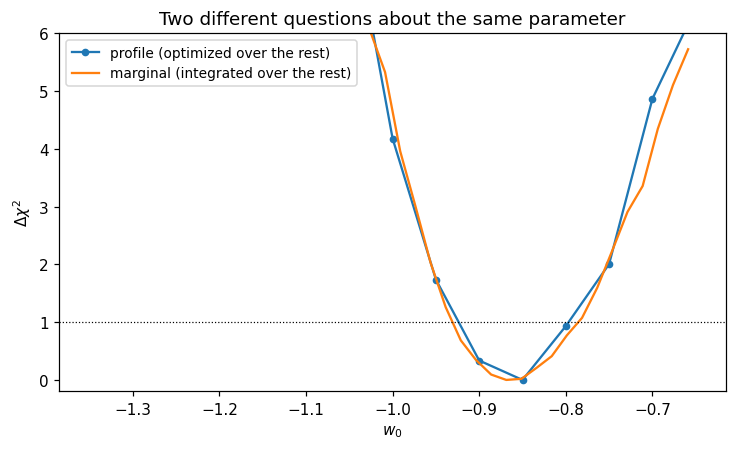

In [11]:
samples = fit.samples_dict()["w0"]

counts, edges = np.histogram(samples, bins=40, range=(w0_grid[0], w0_grid[-1]),
                             density=True)
centres = 0.5 * (edges[1:] + edges[:-1])
marginal_chi2 = -2.0 * np.log(counts / counts.max())

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(profile["values"], profile["delta_chi2"], "o-", lw=1.5, ms=4,
        label="profile (optimized over the rest)")
ax.plot(centres, marginal_chi2, lw=1.5, color="tab:orange",
        label="marginal (integrated over the rest)")
ax.axhline(1.0, color="k", lw=0.8, ls=":")
ax.set_ylim(-0.2, 6.0)
ax.set_xlabel("$w_0$")
ax.set_ylabel(r"$\Delta\chi^2$")
ax.set_title("Two different questions about the same parameter")
ax.legend(fontsize=9)
fig.tight_layout()

## 5. Why this matters: boundaries

The reason the profile exists in this library is a case where the
usual reading of Δχ² fails outright.

**Wilks' theorem is not valid at a boundary.** It says
`Δχ² ~ χ²_k` when the true parameter is *interior* to the space. A
parameter pinned against its limit — a neutrino mass at zero, a
transition redshift running to infinity — violates that, and the
p-value that comes out is simply wrong.

Two places in this library where it bites:

- **`LsCDM`'s `z†`** has a **28-unit cliff** in Δχ² that the
  marginal posterior smoothed over entirely. The profile located it
  in one figure — see
  [`../05-case-studies/lscdm_mcmc.ipynb`](../05-case-studies/lscdm_mcmc.ipynb).
- **A neutrino mass** bounded at `Σm_ν ≥ 0`: the profile bound is
  the honest statement, and the difference from a Bayesian credible
  interval is not a small correction.

`fit.profile()` warm-starts each point from the previous one, since
neighbouring points differ by one small step and their optima are
close. Turn that off (`warm_start=False`) if the surface has a
discontinuity the walk could get trapped on the wrong side of —
which is exactly the `z†` case.

## 6. Which to use

- **Fisher** for a forecast, a proposal covariance, or a quick sanity
  check on whether an MCMC has converged to the right width. Verify
  the Gaussian assumption before quoting it.
- **Profile** when a parameter is near a boundary, when you want a
  frequentist statement, or when a marginal posterior might be
  carrying a volume effect.
- **MCMC** for everything else, and as the reference the other two
  are checked against.

Next: [`evidence_and_model_selection.ipynb`](evidence_and_model_selection.ipynb)
for choosing between models rather than measuring inside one, and
[`tension_statistics.ipynb`](tension_statistics.ipynb) for comparing
datasets.